# CNN Classification for Annihilation Co-ordinates

**Installs**

In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.5/989.5 kB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.5/692.5 kB 37.8 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

In [3]:

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


Loading Root File

In [4]:


ROOT_FILE = "new3merged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


Checking Branches and Channels

In [ ]:


branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

# tree = file["ThreeG_ScannerTCS"]
# df = tree.arrays(branches, library="pd")


# print(df.head())

# print(
    # np.allclose(
        # df["EnergyDeposit_keV"],
        # df["PreEnergy_keV"]
    # )
# )

# print(
    # np.allclose(
        # df["PostEnergy_keV"],
        0
    # )
# )

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1       41           0  -9.865292  50.433369  -1.978315   
1  slurm_35882963_1       41           0 -14.214360  57.286026  -8.685614   
2  slurm_35882963_1       41           1  36.760845 -41.223263   6.484430   
3  slurm_35882963_1       41           1  37.166439 -44.183380   6.876178   
4  slurm_35882963_1       41           2 -21.650757 -10.187035 -46.125771   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0          79.682426     372.859863      293.177429     4.741079    -0.819348   
1         293.177429     293.177429        0.000000     4.741079    -0.819348   
2          43.574589     408.952850      365.378265     4.741079    -0.819348   
3         365.378265     365.378265        0.000000     4.741079    -0.819348   
4          45.603512     240.185104      194.581589     4.741079    -0.819348   

   AnnihilZ_mm  
0   -10.627911  
1   -10.627911  

In [5]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1        0           0  42.213463 -29.997831 -44.219231   
1  slurm_35882963_1        0           1 -39.140385  43.925343  13.321461   
2  slurm_35882963_1        0           2  24.441950 -43.796162   5.251225   
3  slurm_35882963_1       14           0  25.520941  44.251762   1.901691   
4  slurm_35882963_1       14           1  50.743858  24.093874 -56.104988   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         382.314117     382.314117             0.0     4.632441    -1.534016   
1         481.058167     481.058167             0.0     4.632441    -1.534016   
2         158.625549     158.625549             0.0     4.632441    -1.534016   
3         214.394302     214.394302             0.0     0.514280     0.849866   
4         334.142273     334.142273             0.0     0.514280     0.849866   

   AnnihilZ_mm  
0   -10.633850  
1   -10.633850  

Checking Detector Hits and Number of Events

In [6]:
print()
event_sizes = df.groupby(["RunID","EventID"]).size()

print(event_sizes.value_counts())

print("Number of detector hits =", len(df))

print()

print("Number of events =",
      df[["RunID", "EventID"]].drop_duplicates().shape[0])

print()

print(df.describe())


3    23684
Name: count, dtype: int64
Number of detector hits = 71052

Number of events = 23684

            EventID    GammaIndex          X_mm          Y_mm          Z_mm  \
count  71052.000000  71052.000000  71052.000000  71052.000000  71052.000000   
mean   50229.193675      1.000000      1.061749      2.208955     -6.028527   
std    28735.426307      0.816502     32.963696     33.103458     32.988747   
min        0.000000      0.000000    -97.966812    -96.540375    -99.812874   
25%    25521.750000      0.000000    -26.325434    -25.318258    -34.228518   
50%    50419.000000      1.000000      1.793689      3.208224     -9.021889   
75%    74917.500000      2.000000     28.715997     30.252709     20.529098   
max    99997.000000      2.000000     98.725464     98.295921     98.933701   

       EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV   AnnihilX_mm  \
count       71052.000000   71052.000000         71052.0  71052.000000   
mean          338.572937     338.572937      

Defining Image Size

In [8]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-97.96681213378906 98.7254638671875
-96.54037475585938 98.2959213256836
-99.81287384033203 98.93370056152344


In [ ]:
print(tree.num_entries)

71052


In [9]:
print(df.shape)
print(df["EventID"].nunique())
print(df.groupby(["RunID","EventID"]).ngroups)

(71052, 12)
21594
23684


**Building Images for 2D Projections and Regresion Targets**



*   XY
*   XZ
*   YZ




In [17]:

images = []
targets = []
plane_features = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

   #defining vector plane
    points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values

    if len(points) != 3:
        continue

    P1 = points[0]
    P2 = points[1]
    P3 = points[2]

    # two vectors in the plane
    v1 = P2 - P1
    v2 = P3 - P1

    # plane normal
    normal = np.cross(v1, v2)

    # normalise and store
    if np.linalg.norm(normal) == 0:
        continue

    normal = normal / np.linalg.norm(normal)
    plane_features.append(normal)

    # plane equation
    A, B, C = normal
    D = -np.dot(normal, P1)



    # all hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)
plane_features = np.array(plane_features, dtype=np.float32)

print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)
print("Plane features shape:", plane_features.shape)


Building images from 23684 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed
19000 events processed
20000 events processed
21000 events processed
22000 events processed
23000 events processed

Images shape : (23684, 64, 64, 3)
Targets shape: (23684, 3)
Plane features shape: (23684, 3)


In [18]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (23684, 64, 64, 3)
Targets: (23684, 3)

Example target:
[  4.6324406  -1.5340159 -10.63385  ]


In [19]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [15]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (23684, 64, 64, 3)
Targets shape: (23684, 3)

First target:
[  4.6324406  -1.5340159 -10.63385  ]


** Train-Test Split for Model**

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, plane_train, plane_test, y_train, y_test = train_test_split(
    images,
    plane_features,
    targets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


print("Training images :", x_train.shape)
print("Training planes :", plane_train.shape)
print("Training targets:", y_train.shape)

print("Test images :", x_test.shape)
print("Test planes :", plane_test.shape)
print("Test targets:", y_test.shape)

Training images : (18947, 64, 64, 3)
Training planes : (18947, 3)
Training targets: (18947, 3)
Test images : (4737, 64, 64, 3)
Test planes : (4737, 3)
Test targets: (4737, 3)


**Standard Scaler**

In [21]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-1.5680906   1.4992275   0.80531687]


**CNN Model Building - Building Convolutional Layers**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    Input,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout,
    Concatenate
)
#creating model
model = Sequential()

#first feature extraction layer
model.add(
    Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(64,64,3)
    )
)

#reduces image size
model.add(MaxPooling2D())

#second layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu"
    )
)

#reduces image size
model.add(MaxPooling2D())

#third extraction layer
model.add(
    Conv2D(
        64,
        (3,3),#3 image channel
        activation="relu"
    )
)

#reduces image size
model.add(MaxPooling2D())

#cnverts into vector - connect to normal nueral netwrok layers
model.add(Flatten())

#fully connected layer
model.add(Dense(128, activation="relu"))

#reduces overfitting
model.add(Dropout(0.3))

#regression output
model.add(Dense(3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Concatenate
)


# ================================
# Image input branch
# ================================

image_input = Input(shape=(64,64,3), name="image_input")


x = Conv2D(
    16,
    (3,3),
    activation="relu"
)(image_input)

x = MaxPooling2D()(x)


x = Conv2D(
    32,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)


x = Conv2D(
    64,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)


x = Flatten()(x)


# ================================
# Plane input branch
# ================================

plane_input = Input(
    shape=(3,),
    name="plane_input"
)


p = Dense(
    16,
    activation="relu"
)(plane_input)


# ================================
# Combine CNN + plane information
# ================================

combined = Concatenate()([x, p])


combined = Dense(
    128,
    activation="relu"
)(combined)


combined = Dropout(0.3)(combined)


# Regression output
output = Dense(3)(combined)


# Create model
model = Model(
    inputs=[image_input, plane_input],
    outputs=output
)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_input         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2304)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ plane_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2320)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    297,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,123 (1.22 MB)

 Trainable params: 321,123 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

**Compiling Model**

In [23]:

model.summary()

model.compile(
    optimizer="adam",
    loss='mse',
    metrics=["mae", 'accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_input         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2304)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ plane_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2320)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    297,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,123 (1.22 MB)

 Trainable params: 321,123 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

**Training Model**


*   Early Stopping for efficiency
*   20% validation split



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.3607 - loss: 0.9883 - mae: 0.8329 - val_accuracy: 0.4960 - val_loss: 0.9033 - val_mae: 0.7928
Epoch 2/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4948 - loss: 0.8641 - mae: 0.7675 - val_accuracy: 0.5377 - val_loss: 0.8089 - val_mae: 0.7410
Epoch 3/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5157 - loss: 0.8200 - mae: 0.7436 - val_accuracy: 0.5253 - val_loss: 0.7889 - val_mae: 0.7312
Epoch 4/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5293 - loss: 0.7959 - mae: 0.7296 - val_accuracy: 0.5570 - val_loss: 0.7696 - val_mae: 0.7114
Epoch 5/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5403 - loss: 0.7864 - mae: 0.7246 - val_accuracy: 0.5588 - val_loss: 0.7670 - val_mae: 0.7154
Epoch 6/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5430 - loss: 0.7719 - mae: 0.7170 - val_accuracy: 0.5509 - val_loss: 0.7412 - val_mae: 0.7028
Epoch 7/40
1895/1895 ━━━━━━

In [24]:
history = model.fit(
    [x_train, plane_train],
    y_train_scaled,
    validation_data=(
        [x_test, plane_test],
        y_test_scaled
    ),
    epochs=25,
    batch_size=8
)

Epoch 1/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.3754 - loss: 0.9752 - mae: 0.8263 - val_accuracy: 0.4794 - val_loss: 0.8861 - val_mae: 0.7803
Epoch 2/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4895 - loss: 0.8512 - mae: 0.7602 - val_accuracy: 0.5233 - val_loss: 0.8092 - val_mae: 0.7390
Epoch 3/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5168 - loss: 0.8107 - mae: 0.7376 - val_accuracy: 0.5436 - val_loss: 0.7859 - val_mae: 0.7272
Epoch 4/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.5247 - loss: 0.7906 - mae: 0.7260 - val_accuracy: 0.5457 - val_loss: 0.7596 - val_mae: 0.7139
Epoch 5/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5371 - loss: 0.7720 - mae: 0.7160 - val_accuracy: 0.5662 - val_loss: 0.7390 - val_mae: 0.7036
Epoch 6/25
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5373 - loss: 0.7559 - mae: 0.7074 - val_accuracy: 0.5761 - val_loss: 0.7342 - val_mae: 0.7028
Epoch 7/25
2369/2369 ━

**Plotting Training and Validation loss,  MAE and Accuracy**

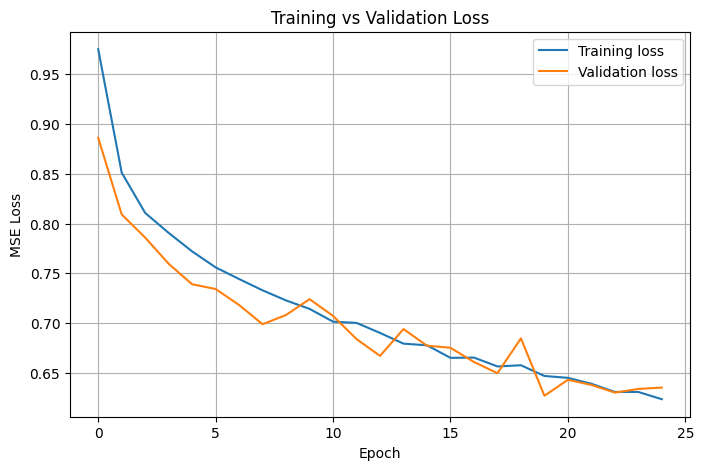

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

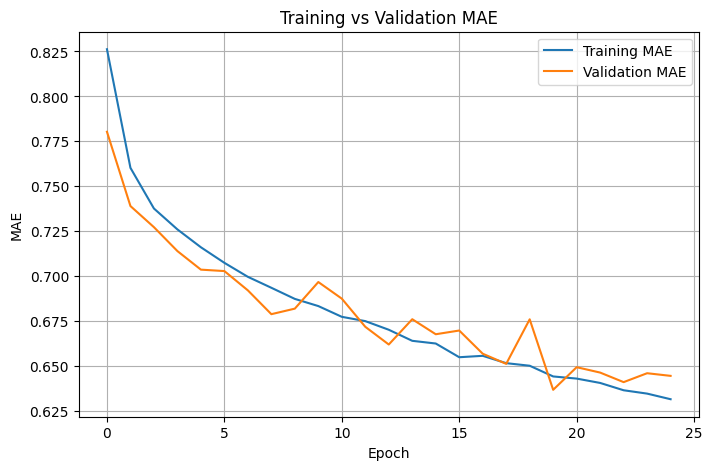

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.grid()

plt.show()

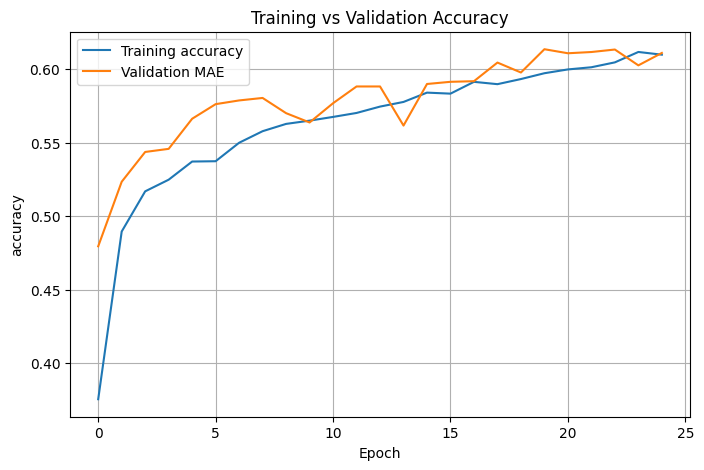

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

**Test Accuracy, loss and MAE**

In [29]:
test_loss, test_mae, test_accuracy = model.evaluate(
    [x_test, plane_test],
    y_test_scaled
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)
print("Test accuracy:", test_accuracy)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6109 - loss: 0.6351 - mae: 0.6445
Test loss: 0.6351184248924255
Test MAE: 0.6444529891014099
Test accuracy: 0.6109352111816406


In [ ]:
prediction_scaled = model.predict(x_test)
prediction = target_scaler.inverse_transform(prediction_scaled)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [30]:
prediction_scaled = model.predict(
    [x_test, plane_test]
)
prediction = target_scaler.inverse_transform(
    prediction_scaled
)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", prediction[i])
    print()

True:      [-0.47320542  4.2953987  -7.0890417 ]
Predicted: [ 0.8208379  4.286647  -6.3383794]

True:      [-1.8619603  4.479793  -6.924948 ]
Predicted: [ 3.1684759  3.9404233 -8.490672 ]

True:      [ 2.2345228  1.8696158 -8.54246  ]
Predicted: [ 0.8138564  3.4657984 -7.354365 ]

True:      [ 1.3888016   0.11342431 -6.7022667 ]
Predicted: [ 1.4514536  3.4801059 -7.4423995]

True:      [ 3.8511534  2.3501887 -9.376963 ]
Predicted: [ 3.5399342  2.5194967 -9.568745 ]



**Position Error**

In [31]:
position_error = prediction[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.7394533 mm


** Reconstruction for X,Y,Z Annihilation - True vs Predicted **

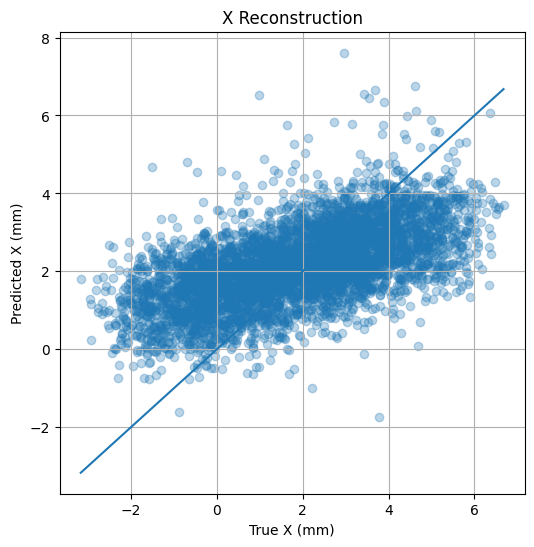

In [32]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

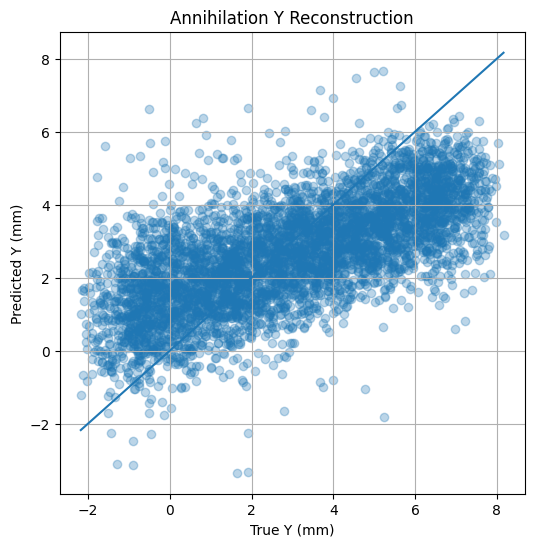

In [33]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    prediction[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

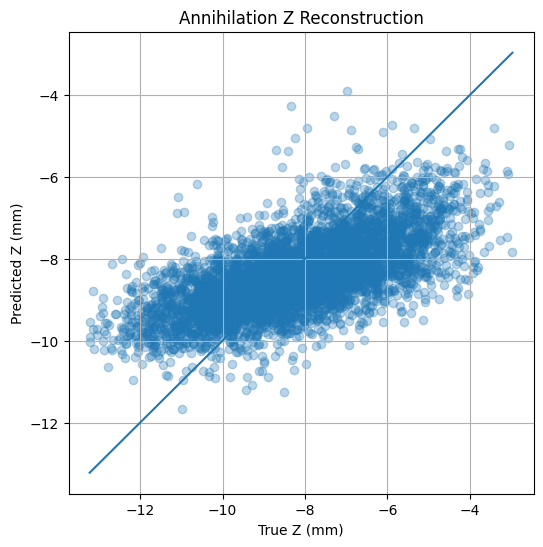

In [34]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    prediction[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

**Comparing to a baseline that is just guessing in the 'middle' position**

In [35]:
# comparing to baseline
mean_position = np.mean(y_train, axis=0)

print(mean_position)
baseline_prediction = np.tile(
    mean_position,
    (len(y_test),1)
)

from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_test,
    baseline_prediction
)

cnn_mse = mean_squared_error(
    y_test,
    prediction
)

print("Baseline MSE:", baseline_mse)
print("CNN MSE:", cnn_mse)

[ 1.8453559  2.9287858 -8.15671  ]
Baseline MSE: 4.707585334777832
CNN MSE: 2.9052183628082275


In [36]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

cnn_mae = mean_absolute_error(
    y_test,
    prediction
)

print("Baseline MAE:", baseline_mae)
print("CNN MAE:", cnn_mae)

Baseline MAE: 1.8075875043869019
CNN MAE: 1.3713477849960327


In [ ]:
print("True X,Y,Z standard deviation:")
print(np.std(y_test, axis=0))

print("\nPredicted X,Y,Z standard deviation:")
print(np.std(prediction, axis=0))

True X,Y,Z standard deviation:
[1.9862987 2.5641627 1.897851 ]

Predicted X,Y,Z standard deviation:
[1.2061489 1.4534307 1.1881562]


In [37]:
#comparing x,y,z separately
for i, coord in enumerate(["X","Y","Z"]):

    baseline = mean_absolute_error(
        y_test[:,i],
        baseline_prediction[:,i]
    )

    cnn = mean_absolute_error(
        y_test[:,i],
        prediction[:,i]
    )

    print(coord)
    print("Baseline:", baseline)
    print("CNN:", cnn)
    print()

X
Baseline: 1.6673718690872192
CNN: 1.3260878324508667

Y
Baseline: 2.207219362258911
CNN: 1.585795283317566

Z
Baseline: 1.5481683015823364
CNN: 1.2021594047546387



In [38]:
from sklearn.metrics import r2_score

print("Overall R²:", r2_score(y_test, prediction))

print("X R²:", r2_score(y_test[:,0], prediction[:,0]))
print("Y R²:", r2_score(y_test[:,1], prediction[:,1]))
print("Z R²:", r2_score(y_test[:,2], prediction[:,2]))

Overall R²: 0.3741011917591095
X R²: 0.317604124546051
Y R²: 0.4221304655075073
Z R²: 0.3825708031654358


**Plotting True and Predicted X,YZ co-ords**

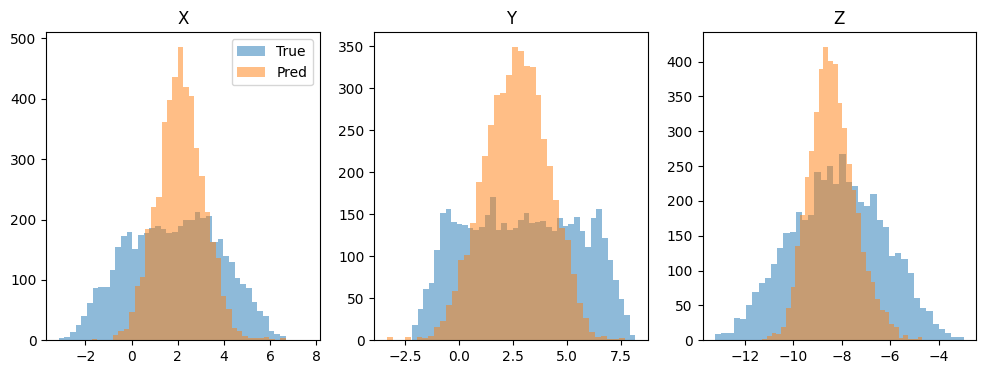

In [39]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(y_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(prediction[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(y_test[:,1], bins=40, alpha=0.5)
plt.hist(prediction[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(y_test[:,2], bins=40, alpha=0.5)
plt.hist(prediction[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

**Plotting Residuals - Difference between CNN model and True Annihilation Positions**

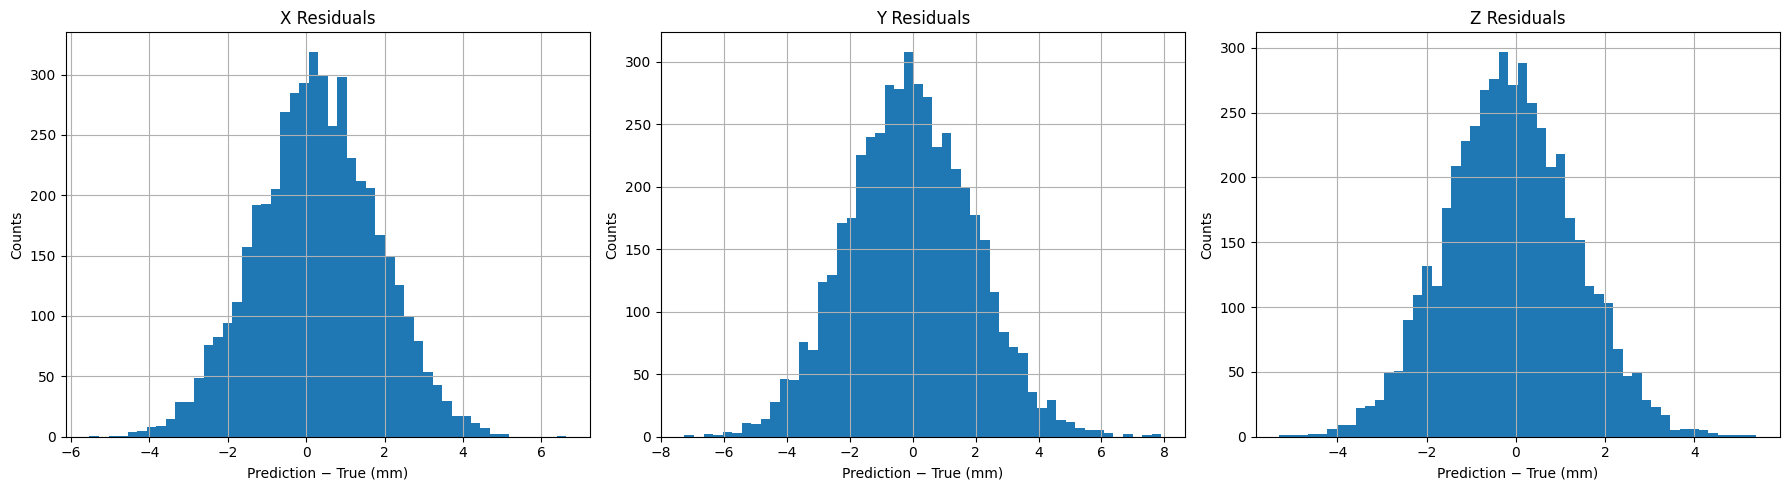

In [ ]:
residuals = prediction - y_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.hist(
        residuals[:, i],
        bins=50
    )

    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction − True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)

plt.tight_layout()
plt.show()


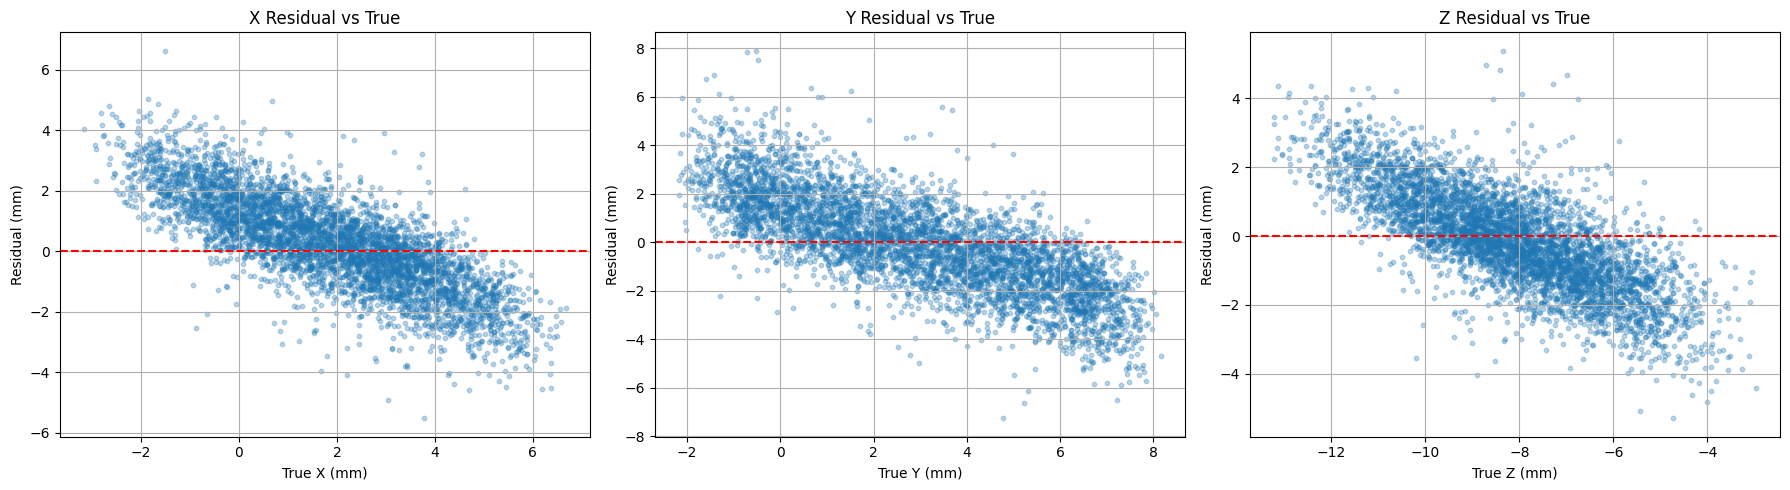

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.scatter(
        y_test[:, i],
        residuals[:, i],
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--"
    )

    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
coords = ["X", "Y", "Z"]

for i in range(3):

    print(f"{coords[i]}")

    print(f"Mean residual: {np.mean(residuals[:,i]):.2f} mm")
    print(f"Std residual : {np.std(residuals[:,i]):.2f} mm")
    print(f"MAE          : {np.mean(np.abs(residuals[:,i])):.2f} mm")

    print()

X
Mean residual: 0.27 mm
Std residual : 1.55 mm
MAE          : 1.26 mm

Y
Mean residual: -0.07 mm
Std residual : 1.99 mm
MAE          : 1.59 mm

Z
Mean residual: -0.12 mm
Std residual : 1.44 mm
MAE          : 1.15 mm

